# Test 3: Quantum Output Analysis

Examine what the quantum circuit actually outputs. Hook into the QuantumBlock,
collect PauliZ expectations across all validation samples, and analyze.

**Key question:** Is the quantum circuit computing something meaningful and sample-dependent?

In [1]:
from setup_helpers import *
from sklearn.decomposition import PCA

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
data = load_data()
print("Model and data loaded.")

Model and data loaded.


## 3.1 — Collect quantum outputs via hooks

In [2]:
quantum_outputs = []
quantum_angles = []
head_contexts = []

def hook_quantum_block(module, input, output):
    quantum_outputs.append(output.detach().cpu().numpy())

def hook_projector(module, input, output):
    quantum_angles.append(output.detach().cpu().numpy())

def hook_classical_head(module, input, output):
    head_contexts.append(input[0].detach().cpu().numpy())

h1 = model.quantum_block.register_forward_hook(hook_quantum_block)
h2 = model.projector.register_forward_hook(hook_projector)
h3 = model.classical_head.register_forward_hook(hook_classical_head)

# Run validation data through model
split = data.val
with torch.inference_mode():
    for start in range(0, split.rows, BATCH_SIZE):
        stop = min(start + BATCH_SIZE, split.rows)
        idx = torch.arange(start, stop)
        aux = split.aux[idx].to(device)
        spectra = split.spectra[idx].to(device)
        _ = model(aux, spectra, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)

h1.remove()
h2.remove()
h3.remove()

Q = np.concatenate(quantum_outputs, axis=0)  # (N_val, 8)
A = np.concatenate(quantum_angles, axis=0)    # (N_val, 8)
H = np.concatenate(head_contexts, axis=0)     # (N_val, 256)
print(f"Collected quantum outputs: {Q.shape}")
print(f"Collected quantum angles: {A.shape}")
print(f"Collected head contexts: {H.shape}")

Collected quantum outputs: (4142, 8)
Collected quantum angles: (4142, 8)
Collected head contexts: (4142, 256)


## 3.2 — Quantum output statistics

In [3]:
stats = pd.DataFrame({
    "Qubit": [f"q{i}" for i in range(Q.shape[1])],
    "Mean": Q.mean(axis=0),
    "Std": Q.std(axis=0),
    "Min": Q.min(axis=0),
    "Max": Q.max(axis=0),
    "Range": Q.max(axis=0) - Q.min(axis=0),
}).set_index("Qubit")
display(stats)

print(f"\nOverall: mean std across qubits = {Q.std(axis=0).mean():.4f}")
if Q.std(axis=0).mean() < 0.01:
    print("WARNING: Quantum outputs are near-constant — circuit not doing sample-dependent computation")
else:
    print("Quantum outputs vary across samples — circuit is sample-dependent")

,Mean,Std,Min,Max,Range
Qubit,,,,,
q0,-0.001006,0.064829,-0.625815,0.335535,0.961350
q1,-0.044420,0.541761,-0.997346,0.970951,1.968298
q2,-0.148785,0.357669,-0.931944,0.976164,1.908107
q3,0.011179,0.243482,-0.861510,0.797881,1.659390
q4,-0.035373,0.145660,-0.790362,0.780219,1.570581
q5,0.002688,0.088178,-0.678601,0.431661,1.110262
q6,-0.010338,0.083899,-0.388419,0.630688,1.019107
q7,0.008014,0.049428,-0.278535,0.504703,0.783238



Overall: mean std across qubits = 0.1969
Quantum outputs vary across samples — circuit is sample-dependent


In [4]:
# Angle statistics
angle_stats = pd.DataFrame({
    "Qubit": [f"q{i}" for i in range(A.shape[1])],
    "Mean": A.mean(axis=0),
    "Std": A.std(axis=0),
    "Min": A.min(axis=0),
    "Max": A.max(axis=0),
}).set_index("Qubit")
print("Input angle statistics (output of QuantumProjector):")
display(angle_stats)

Input angle statistics (output of QuantumProjector):


,Mean,Std,Min,Max
Qubit,,,,
q0,-1.249906,1.432123,-3.072580,2.774927
q1,2.404143,0.815817,-2.941777,3.036355
q2,1.451970,1.282865,-3.000344,3.082591
q3,1.956297,0.744166,-2.588313,3.049402
q4,-1.510734,1.200239,-2.997651,2.606049
q5,1.687045,0.775314,-2.083416,3.055200
q6,-2.830609,0.432080,-3.050623,2.929576
q7,-1.391401,0.667700,-2.322432,2.706892


## 3.3 — Histograms of qubit outputs

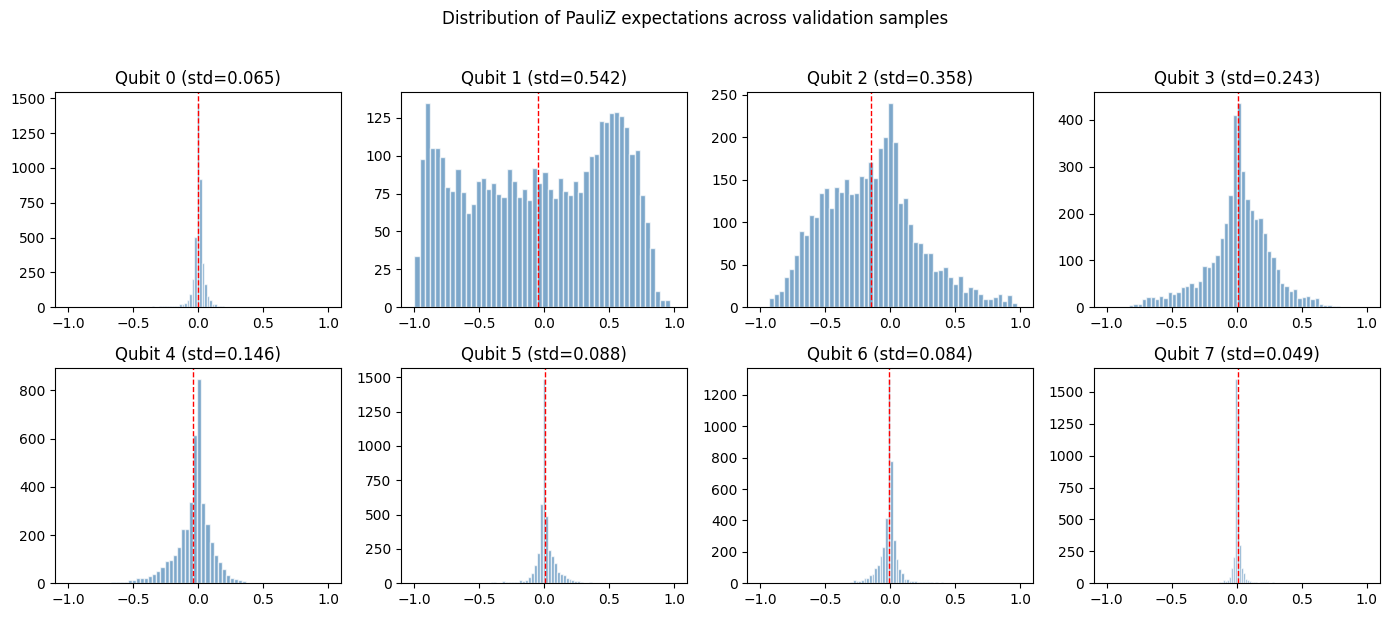

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.hist(Q[:, i], bins=50, alpha=0.7, color="steelblue", edgecolor="white")
    ax.set_title(f"Qubit {i} (std={Q[:, i].std():.3f})")
    ax.set_xlim(-1.1, 1.1)
    ax.axvline(Q[:, i].mean(), color="red", linestyle="--", linewidth=1)
plt.suptitle("Distribution of PauliZ expectations across validation samples", y=1.02)
plt.tight_layout()
plt.show()

## 3.4 — Correlation: quantum outputs vs targets

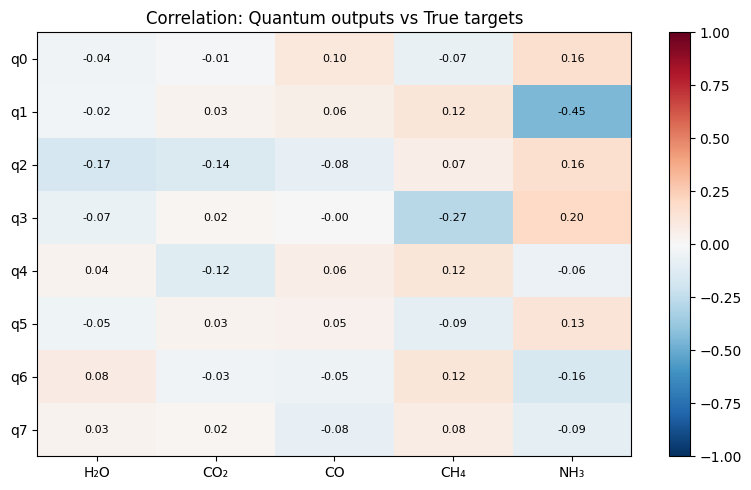

Max |correlation| between any qubit output and target: 0.4529


In [6]:
# True targets (unscaled)
true_orig = data.target_scaler.inverse_transform(split.targets.cpu().numpy())

# Correlation matrix: qubits × targets
corr = np.zeros((Q.shape[1], len(TARGET_NAMES)))
for i in range(Q.shape[1]):
    for j in range(len(TARGET_NAMES)):
        corr[i, j] = np.corrcoef(Q[:, i], true_orig[:, j])[0, 1]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(TARGET_NAMES)))
ax.set_xticklabels(TARGET_NAMES)
ax.set_yticks(range(Q.shape[1]))
ax.set_yticklabels([f"q{i}" for i in range(Q.shape[1])])
ax.set_title("Correlation: Quantum outputs vs True targets")
for i in range(Q.shape[1]):
    for j in range(len(TARGET_NAMES)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

max_corr = np.abs(corr).max()
print(f"Max |correlation| between any qubit output and target: {max_corr:.4f}")

## 3.5 — PCA of quantum outputs

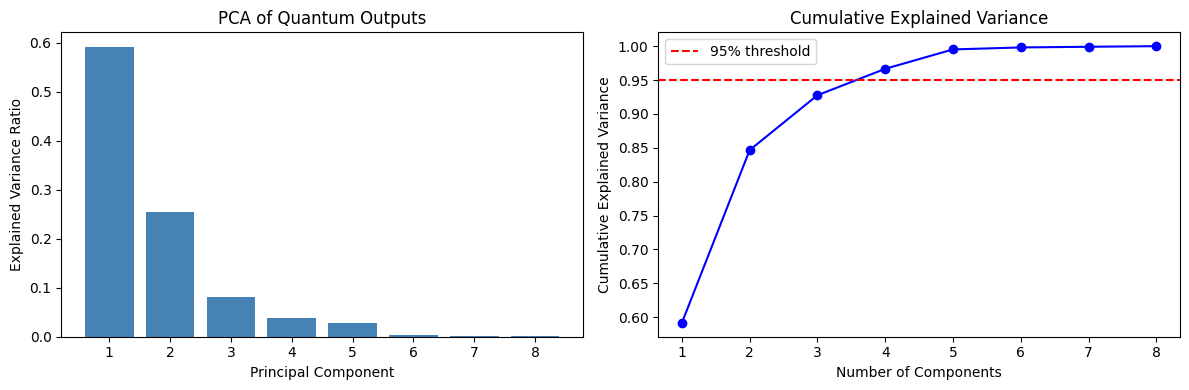

Components for 95% variance: 4 out of 8
Effective dimensionality: 4


In [7]:
pca = PCA(n_components=Q.shape[1])
pca.fit(Q)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, Q.shape[1]+1), pca.explained_variance_ratio_, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA of Quantum Outputs")

cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, Q.shape[1]+1), cumvar, "bo-")
axes[1].axhline(0.95, color="red", linestyle="--", label="95% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

n_95 = int(np.searchsorted(cumvar, 0.95) + 1)
print(f"Components for 95% variance: {n_95} out of {Q.shape[1]}")
print(f"Effective dimensionality: {n_95}")

## 3.6 — Residual correlation analysis

Check if quantum correction correlates with classical prediction error.
If quantum_correction ∝ (true - classical_pred), the quantum branch learned to fix classical mistakes.

In [8]:
# Get classical-only predictions
m_off = evaluate(model, data.val, data.target_scaler, enable_quantum=False)
classical_pred = m_off["pred_orig"]
classical_residual = true_orig - classical_pred  # what classical gets wrong

# Get quantum correction = quantum_on_pred - classical_pred (at scale=0.5)
m_on = evaluate(model, data.val, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
quantum_pred = m_on["pred_orig"]
quantum_correction = quantum_pred - classical_pred  # what quantum adds

# Per-target correlation between residual and correction
print("Correlation between classical residual and quantum correction:")
print("(Positive = quantum corrects in right direction)\n")

corrs = []
for i, name in enumerate(TARGET_NAMES):
    r = np.corrcoef(classical_residual[:, i], quantum_correction[:, i])[0, 1]
    corrs.append(r)
    direction = "CORRECTS" if r > 0.1 else ("OPPOSES" if r < -0.1 else "UNCORRELATED")
    print(f"  {name}: r = {r:+.4f} → {direction}")

print(f"\nMean correlation: {np.mean(corrs):+.4f}")

Correlation between classical residual and quantum correction:
(Positive = quantum corrects in right direction)

  H₂O: r = +0.2300 → CORRECTS
  CO₂: r = +0.3410 → CORRECTS
  CO: r = +0.2030 → CORRECTS
  CH₄: r = +0.1725 → CORRECTS
  NH₃: r = +0.1566 → CORRECTS

Mean correlation: +0.2206


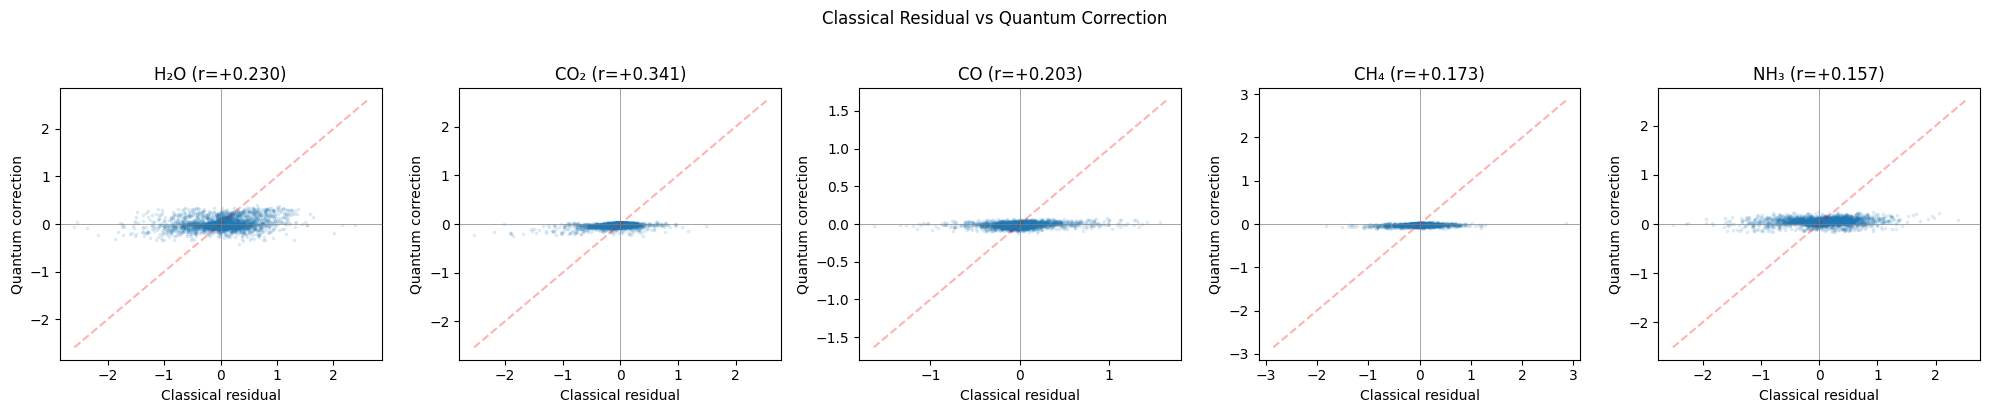

In [9]:
# Scatter: residual vs correction for each target
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, name) in enumerate(zip(axes, TARGET_NAMES)):
    ax.scatter(classical_residual[:, i], quantum_correction[:, i], alpha=0.1, s=3)
    ax.set_xlabel("Classical residual")
    ax.set_ylabel("Quantum correction")
    r = corrs[i]
    ax.set_title(f"{name} (r={r:+.3f})")
    # Reference line: perfect correction would be y=x
    lim = max(abs(classical_residual[:, i]).max(), abs(quantum_correction[:, i]).max())
    ax.plot([-lim, lim], [-lim, lim], "r--", alpha=0.3, label="y=x")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.suptitle("Classical Residual vs Quantum Correction", y=1.02)
plt.tight_layout()
plt.show()

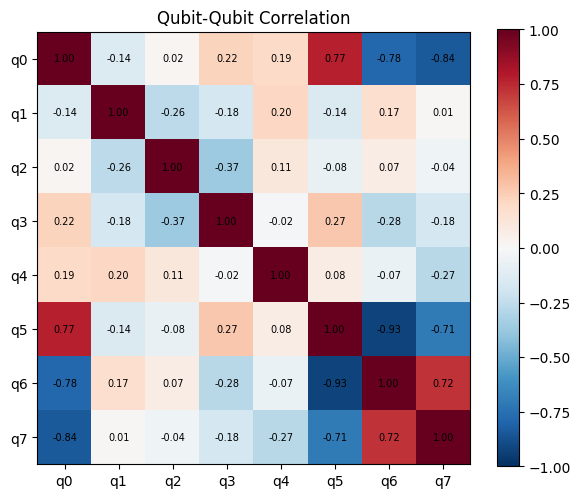

In [10]:
# Qubit-qubit correlation
qq_corr = np.corrcoef(Q.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(qq_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(Q.shape[1]))
ax.set_xticklabels([f"q{i}" for i in range(Q.shape[1])])
ax.set_yticks(range(Q.shape[1]))
ax.set_yticklabels([f"q{i}" for i in range(Q.shape[1])])
ax.set_title("Qubit-Qubit Correlation")
for i in range(Q.shape[1]):
    for j in range(Q.shape[1]):
        ax.text(j, i, f"{qq_corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()